# Alpha sweep — empirical search for the best audio/text mixing weight

## 1. Setup — load catalogue, embeddings, scaler, K-Means, results_df

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.preprocess import preprocess_pipeline
from src.embeddings import build_song_embeddings
from src.recommender import recommend
from src.evaluate import precision_at_k
from src.test_set import TEST_PLAYLISTS, get_ground_truth_indices
from src.baselines import recommend_audio_only, recommend_text_only

TOP_K = 10
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
EMBED_PATH = os.path.join(DATA_DIR, 'song_embeddings.npy')
TEXT_EMBED_PATH = os.path.join(DATA_DIR, 'text_embeddings.npy')

print('Loading catalogue, scaler, K-Means...')
df, audio_features, scaler, kmeans = preprocess_pipeline(os.path.join(DATA_DIR, 'spotify_data.csv'))
print(f'  catalogue: {len(df):,} rows')

print('Loading embeddings...')
if os.path.exists(EMBED_PATH) and os.path.exists(TEXT_EMBED_PATH):
    song_embeddings = np.load(EMBED_PATH)
    text_embeddings = np.load(TEXT_EMBED_PATH)
    print(f'  loaded from disk: text_embeddings shape = {text_embeddings.shape}')
else:
    print('  embeddings file missing — building from scratch (this takes ~2h on CPU)')
    song_embeddings, text_embeddings = build_song_embeddings(df, audio_features)
    np.save(EMBED_PATH, song_embeddings)
    np.save(TEXT_EMBED_PATH, text_embeddings)

print(f'Setup complete. {len(TEST_PLAYLISTS)} test playlists ready.')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding vibe anchors...
Vibe anchors ready.
Loading catalogue, scaler, K-Means...
  catalogue: 1,159,748 rows
Loading embeddings...
  loaded from disk: text_embeddings shape = (1159748, 384)
Setup complete. 15 test playlists ready.


## 2. Compute endpoint Precision@10 (alpha = 0.0 and 1.0)

In [2]:
def mean_precision_for_baseline(baseline_fn):
    precs = []
    for tp in TEST_PLAYLISTS:
        relevant = list(get_ground_truth_indices(df, tp))
        recs, _ = baseline_fn(
            tp['name'], df, text_embeddings,
            top_k=TOP_K, scaler=scaler, kmeans=kmeans,
        )
        recommended = recs.index.tolist()
        precs.append(precision_at_k(recommended, relevant, TOP_K))
    return float(np.mean(precs)), float(np.std(precs))

text_only_p,  text_only_std  = mean_precision_for_baseline(recommend_text_only)
audio_only_p, audio_only_std = mean_precision_for_baseline(recommend_audio_only)

print(f'text_only  (= alpha 0.0): P@10 = {text_only_p:.4f}  std = {text_only_std:.4f}')
print(f'audio_only (= alpha 1.0): P@10 = {audio_only_p:.4f}  std = {audio_only_std:.4f}')

c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

text_only  (= alpha 0.0): P@10 = 0.6800  std = 0.3763
audio_only (= alpha 1.0): P@10 = 0.6533  std = 0.3721


## 3. Sweep alpha from 0.1 to 0.9 in steps of 0.1

In [3]:
ALPHA_VALUES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

alpha_rows = []
for alpha in ALPHA_VALUES:
    precs = []
    for tp in TEST_PLAYLISTS:
        relevant = list(get_ground_truth_indices(df, tp))
        recs, _ = recommend(
            tp['name'], df, text_embeddings,
            top_k=TOP_K, alpha=alpha,
            scaler=scaler, kmeans=kmeans,
        )
        recommended = recs.index.tolist()
        precs.append(precision_at_k(recommended, relevant, TOP_K))
    mean_p = float(np.mean(precs))
    std_p  = float(np.std(precs))
    alpha_rows.append({'alpha': alpha, 'P@10_mean': mean_p, 'P@10_std': std_p})
    print(f'alpha={alpha:.1f}  mean P@10 = {mean_p:.4f}  std = {std_p:.4f}')

all_rows = (
    [{'alpha': 0.0, 'P@10_mean': text_only_p,  'P@10_std': text_only_std}]
    + alpha_rows
    + [{'alpha': 1.0, 'P@10_mean': audio_only_p, 'P@10_std': audio_only_std}]
)
alpha_df = pd.DataFrame(all_rows)

best_idx   = alpha_df['P@10_mean'].idxmax()
best_alpha = float(alpha_df.loc[best_idx, 'alpha'])
best_prec  = float(alpha_df.loc[best_idx, 'P@10_mean'])
print()
print(f'Best alpha = {best_alpha:.1f}  with mean P@10 = {best_prec:.4f}')
alpha_df

c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

alpha=0.1  mean P@10 = 0.7000  std = 0.3540


c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

alpha=0.2  mean P@10 = 0.6933  std = 0.3568


c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

...

c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

alpha=0.8  mean P@10 = 0.8467  std = 0.2802


c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor T

alpha=0.9  mean P@10 = 0.8800  std = 0.2587

Best alpha = 0.9  with mean P@10 = 0.8800


,alpha,P@10_mean,P@10_std
0,0.0,0.680000,0.376298
1,0.1,0.700000,0.354024
2,0.2,0.693333,0.356776
3,0.3,0.740000,0.324140
4,0.4,0.773333,0.267000
5,0.5,0.813333,0.249978
6,0.6,0.806667,0.259401
7,0.7,0.853333,0.233429
8,0.8,0.846667,0.280159
9,0.9,0.880000,0.258715


## 4. Plot the sweep curve and save artefacts

Saved table: c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\data\alpha_sweep_results.csv
Saved plot:  c:\Users\janis\OneDrive\Documents\TSI Studies\Bachelor Thesis\data\alpha_sweep_plot.png


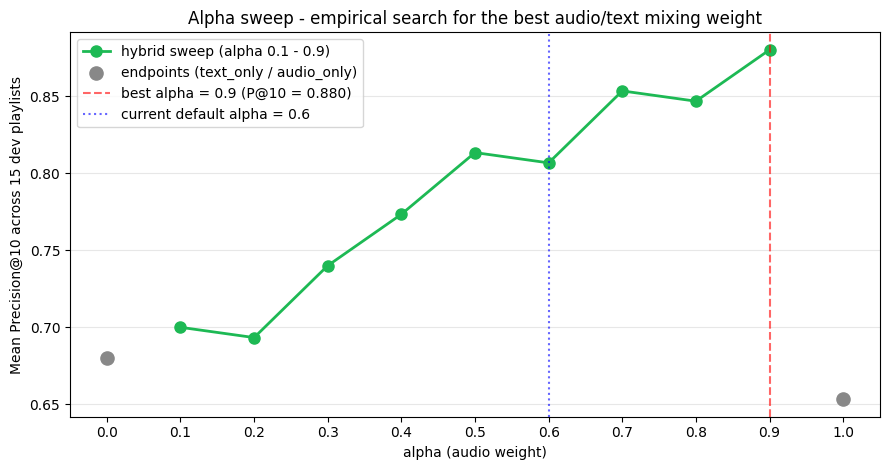

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.8))

sweep_only = alpha_df[(alpha_df['alpha'] > 0.0) & (alpha_df['alpha'] < 1.0)]
ax.plot(sweep_only['alpha'], sweep_only['P@10_mean'],
        marker='o', color='#1db954', linewidth=2, markersize=8,
        label='hybrid sweep (alpha 0.1 - 0.9)')

ax.scatter([0.0, 1.0], [text_only_p, audio_only_p],
           color='#888888', s=90, zorder=5,
           label='endpoints (text_only / audio_only)')

ax.axvline(best_alpha, color='red', linestyle='--', alpha=0.6,
           label=f'best alpha = {best_alpha:.1f} (P@10 = {best_prec:.3f})')
ax.axvline(0.6, color='blue', linestyle=':', alpha=0.6,
           label='current default alpha = 0.6')

ax.set_xlabel('alpha (audio weight)')
ax.set_ylabel('Mean Precision@10 across 15 dev playlists')
ax.set_title('Alpha sweep - empirical search for the best audio/text mixing weight')
ax.set_xticks(np.arange(0.0, 1.1, 0.1))
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()

out_csv = os.path.join(DATA_DIR, 'alpha_sweep_results.csv')
out_png = os.path.join(DATA_DIR, 'alpha_sweep_plot.png')
alpha_df.to_csv(out_csv, index=False)
fig.savefig(out_png, dpi=150, bbox_inches='tight')
print(f'Saved table: {out_csv}')
print(f'Saved plot:  {out_png}')

plt.show()

## 5. Interpretation